In [6]:
from google.colab import files
files.upload()

Saving telecom_churn_limpio.csv to telecom_churn_limpio.csv


{'telecom_churn_limpio.csv': b'customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,Antiguedad_meses,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias\n0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Cheque f\xc3\xadsico,65.6,593.3,2.19\n0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Cheque f\xc3\xadsico,59.9,542.4,2.0\n0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Cheque electr\xc3\xb3nico,73.9,280.85,2.46\n0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Cheque electr\xc3\xb3nico,98.0,1237.85,3.27\n0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Che

In [7]:
df = pd.read_csv("telecom_churn_limpio.csv")


In [8]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,Antiguedad_meses,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Cheque físico,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Cheque físico,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Cheque físico,83.9,267.40,2.80


In [9]:
df.shape

(7256, 22)

In [10]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'Antiguedad_meses',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'Tipo_Contrato',
       'account_PaperlessBilling', 'Metodo_Pago', 'Cargo_Mensual',
       'Cargo_Total', 'Cuentas_Diarias'],
      dtype='object')

In [11]:
df = df.drop(columns=['customerID'])

In [12]:
df.columns

Index(['Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'Antiguedad_meses',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'Tipo_Contrato',
       'account_PaperlessBilling', 'Metodo_Pago', 'Cargo_Mensual',
       'Cargo_Total', 'Cuentas_Diarias'],
      dtype='object')

#Eliminación de variables irrelevantes

En esta etapa se eliminaron columnas que no aportan valor al análisis predictivo.
La variable customerID corresponde a un identificador único para cada cliente y no contiene información relevante para predecir la cancelación del servicio.

Mantener este tipo de variables puede introducir ruido en los modelos de Machine Learning, por lo que fue removida del conjunto de datos antes de continuar con el proceso de modelado.

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [14]:
df_encoded.head()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,Antiguedad_meses,phone_PhoneService,account_PaperlessBilling,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,...,internet_TechSupport_Yes,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Cheque físico,Metodo_Pago_Tarjeta automática,Metodo_Pago_Transferencia automática
0,0.0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,False,False,True,False,True,False,False
1,0.0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,False,True,False,False
2,1.0,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,False,False,False,False
3,1.0,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,False,True,False,True,False,False,False,False,False
4,1.0,1,1,0,3,1,1,83.9,267.40,2.80,...,True,False,True,False,False,False,False,True,False,False


In [15]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   float64
 1   customer_SeniorCitizen                         7256 non-null   int64  
 2   customer_Partner                               7256 non-null   int64  
 3   customer_Dependents                            7256 non-null   int64  
 4   Antiguedad_meses                               7256 non-null   int64  
 5   phone_PhoneService                             7256 non-null   int64  
 6   account_PaperlessBilling                       7256 non-null   int64  
 7   Cargo_Mensual                                  7256 non-null   float64
 8   Cargo_Total                                    7256 non-null   float64
 9   Cuentas_Diarias                                7256 

In [16]:
df_encoded = df_encoded.dropna(subset=['Churn'])

In [17]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7255
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   float64
 1   customer_SeniorCitizen                         7032 non-null   int64  
 2   customer_Partner                               7032 non-null   int64  
 3   customer_Dependents                            7032 non-null   int64  
 4   Antiguedad_meses                               7032 non-null   int64  
 5   phone_PhoneService                             7032 non-null   int64  
 6   account_PaperlessBilling                       7032 non-null   int64  
 7   Cargo_Mensual                                  7032 non-null   float64
 8   Cargo_Total                                    7032 non-null   float64
 9   Cuentas_Diarias                                7032 non-n

In [18]:
df_encoded = df_encoded.astype(int)

In [19]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7255
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Churn                                          7032 non-null   int64
 1   customer_SeniorCitizen                         7032 non-null   int64
 2   customer_Partner                               7032 non-null   int64
 3   customer_Dependents                            7032 non-null   int64
 4   Antiguedad_meses                               7032 non-null   int64
 5   phone_PhoneService                             7032 non-null   int64
 6   account_PaperlessBilling                       7032 non-null   int64
 7   Cargo_Mensual                                  7032 non-null   int64
 8   Cargo_Total                                    7032 non-null   int64
 9   Cuentas_Diarias                                7032 non-null   int64
 10  custo

#Tratamiento de valores nulos y tipos de datos

Durante la preparación de los datos se identificaron valores nulos en la variable objetivo Churn. Debido a que los modelos de Machine Learning requieren una variable objetivo completa, se eliminaron las filas con valores faltantes.

Adicionalmente, algunas variables generadas mediante One-Hot Encoding se encontraban en formato booleano (True / False). Estas fueron convertidas a formato numérico (1 / 0) para garantizar compatibilidad con los algoritmos de clasificación.

In [20]:
df_encoded['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [21]:
df_encoded['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


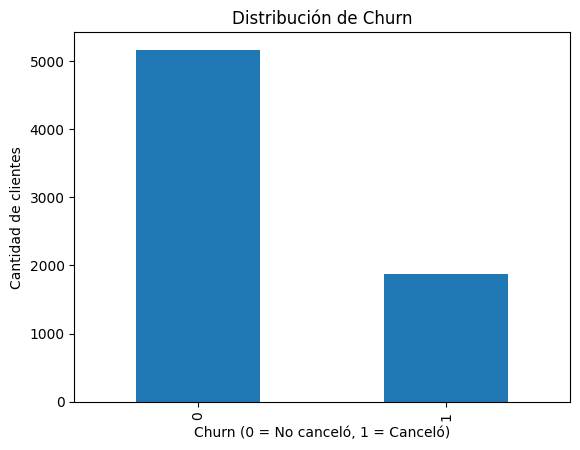

In [22]:
import matplotlib.pyplot as plt

df_encoded['Churn'].value_counts().plot(kind='bar')

plt.title("Distribución de Churn")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Cantidad de clientes")
plt.show()

#Distribución de la variable objetivo

Se analizó la distribución de la variable Churn con el objetivo de identificar posibles desbalances entre las clases. Los resultados muestran que aproximadamente el 73% de los clientes permanecen activos, mientras que alrededor del 27% cancelaron el servicio.

Este comportamiento indica un desbalance moderado en las clases, lo cual es común en problemas de churn. Este aspecto debe tenerse en cuenta durante el entrenamiento de los modelos predictivos, ya que algunos algoritmos pueden verse afectados por distribuciones desbalanceadas y tender a favorecer la clase mayoritaria.

In [23]:
from sklearn.preprocessing import StandardScaler

In [25]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Antes de aplicar la estandarización, los datos fueron divididos en conjuntos de entrenamiento y prueba. Posteriormente se utilizó StandardScaler para normalizar las variables numéricas, evitando que las diferencias de escala afecten el desempeño de los modelos de machine learning.

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Normalización de los datos

Se evaluó la necesidad de normalizar los datos antes de entrenar los modelos predictivos. Algunas variables numéricas del conjunto de datos presentan escalas diferentes, como Cargo_Total, Cargo_Mensual y Antiguedad_meses.

En modelos basados en distancia, como Regresión Logística, KNN o SVM, estas diferencias de escala pueden afectar el desempeño del modelo, ya que las variables con valores más grandes pueden dominar el proceso de aprendizaje.

Para evitar este problema, se aplicó una estandarización utilizando StandardScaler, que transforma las variables para que tengan una media de 0 y una desviación estándar de 1.

Es importante destacar que este preprocesamiento se aplicó únicamente a los datos de entrenamiento para evitar filtración de información hacia el conjunto de prueba.

In [29]:
correlacion = df_encoded.corr()

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

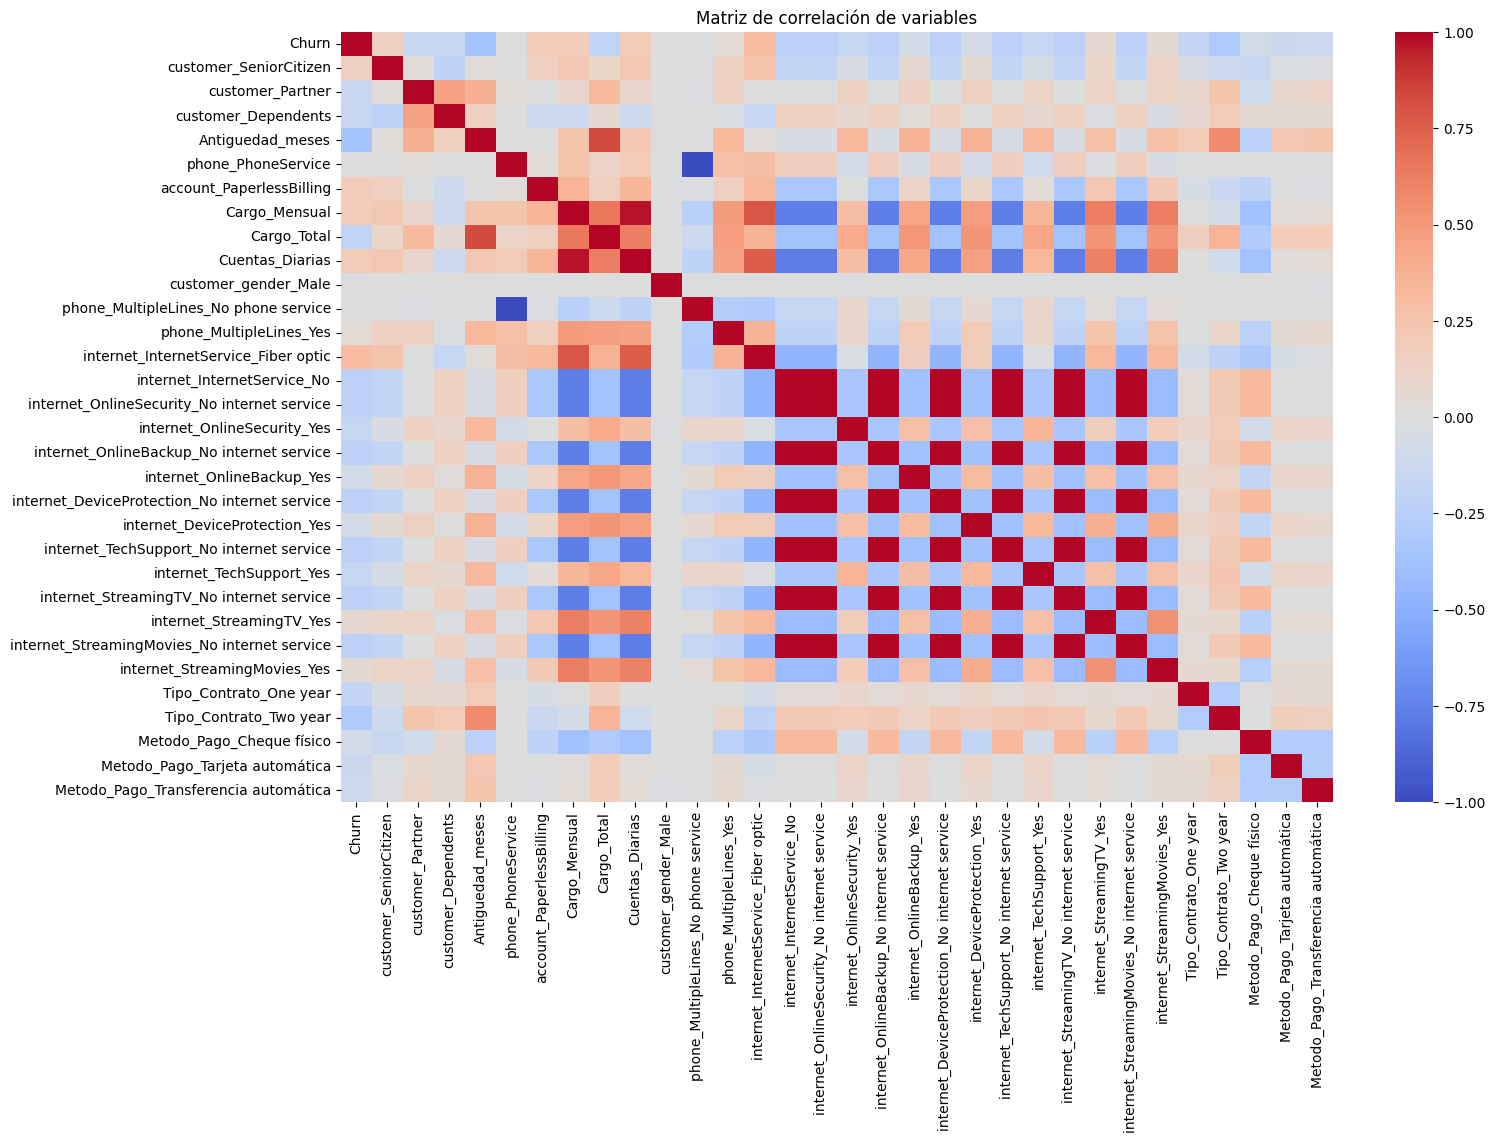

In [31]:
plt.figure(figsize=(16,10))
sns.heatmap(correlacion, cmap="coolwarm", annot=False)

plt.title("Matriz de correlación de variables")
plt.show()

In [32]:
correlacion['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
internet_InternetService_Fiber optic,0.307463
Cuentas_Diarias,0.195518
Cargo_Mensual,0.192922
account_PaperlessBilling,0.191454
customer_SeniorCitizen,0.150541
internet_StreamingTV_Yes,0.063254
internet_StreamingMovies_Yes,0.060860
phone_MultipleLines_Yes,0.040033
phone_PhoneService,0.011691


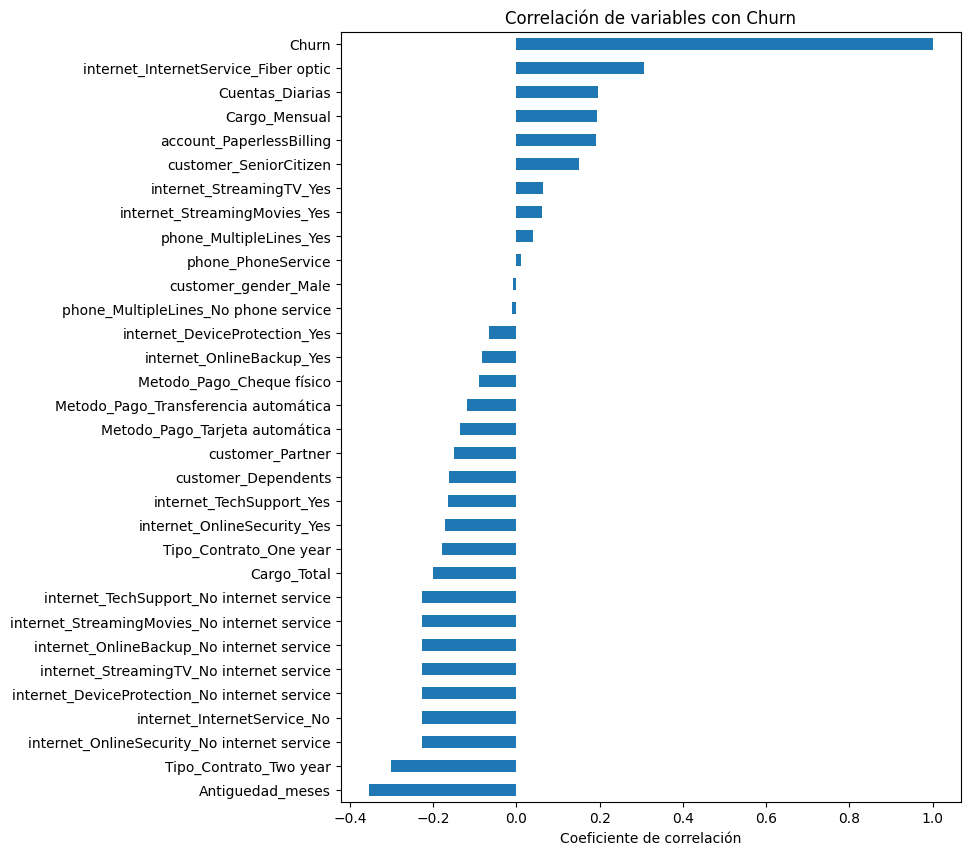

In [33]:
plt.figure(figsize=(8,10))

correlacion_churn = correlacion['Churn'].sort_values()

correlacion_churn.plot(kind='barh')

plt.title("Correlación de variables con Churn")
plt.xlabel("Coeficiente de correlación")
plt.show()

#Análisis de correlación

Se calculó la matriz de correlación entre las variables del conjunto de datos con el objetivo de identificar posibles relaciones entre ellas y su asociación con la variable objetivo Churn.

El análisis permitió identificar que algunas variables presentan una mayor relación con la cancelación del servicio, como el tipo de contrato, el nivel de cargos mensuales y el tipo de servicio de internet.

En particular, variables como Antiguedad_meses y los contratos de largo plazo presentan correlaciones negativas con el churn, lo que sugiere que los clientes con mayor tiempo en la empresa o con contratos más largos tienden a cancelar menos el servicio.

Por otro lado, variables relacionadas con mayores cargos o ciertos tipos de servicio pueden mostrar correlaciones positivas con la cancelación.

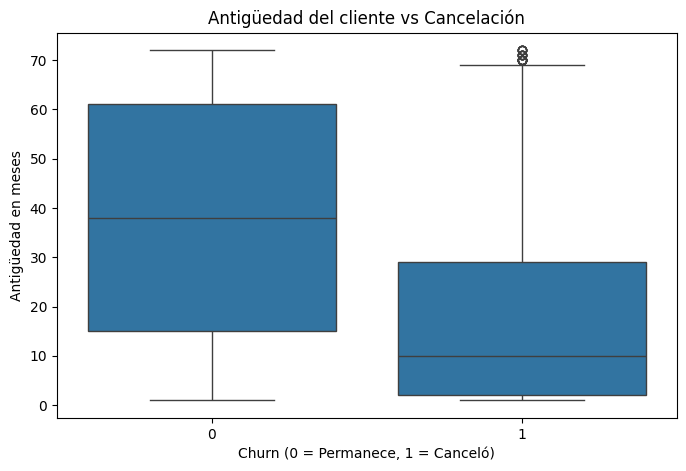

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Antiguedad_meses', data=df_encoded)

plt.title("Antigüedad del cliente vs Cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Canceló)")
plt.ylabel("Antigüedad en meses")

plt.show()

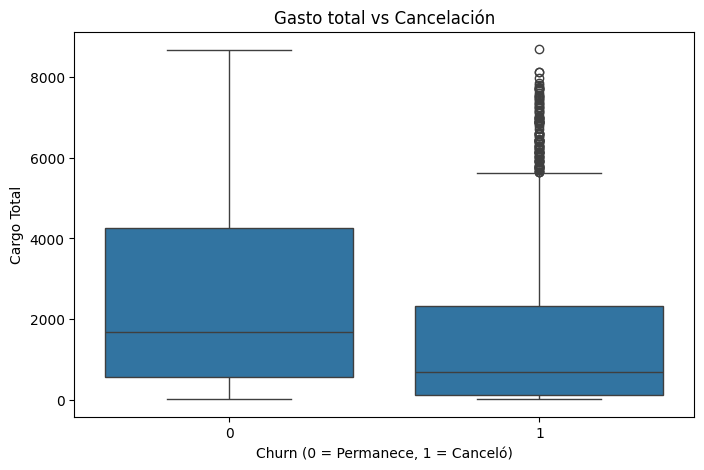

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Cargo_Total', data=df_encoded)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Canceló)")
plt.ylabel("Cargo Total")

plt.show()

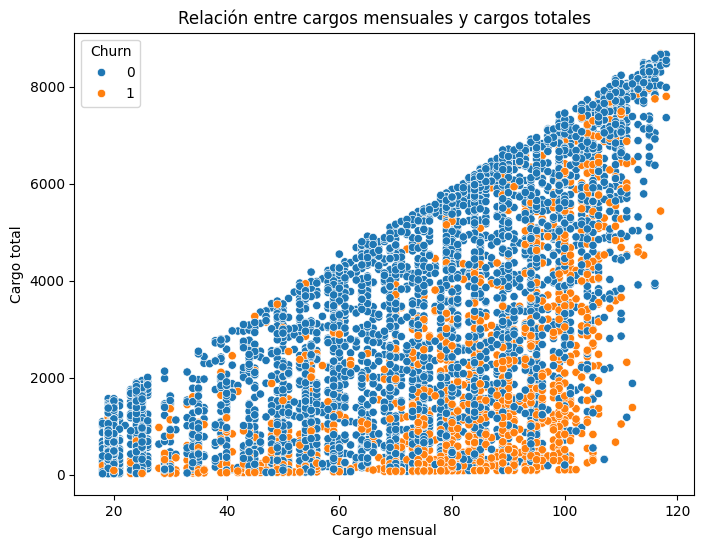

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Cargo_Mensual',
    y='Cargo_Total',
    hue='Churn',
    data=df_encoded
)

plt.title("Relación entre cargos mensuales y cargos totales")
plt.xlabel("Cargo mensual")
plt.ylabel("Cargo total")

plt.show()

#Relación entre variables numéricas y cancelación

Se analizaron algunas variables numéricas relevantes para identificar posibles patrones asociados con la cancelación del servicio.

En el caso de la antigüedad del cliente, se observa que los clientes que cancelan tienden a tener menor tiempo de permanencia en la empresa, lo que sugiere que el riesgo de cancelación es mayor durante los primeros meses de relación con el servicio.

Respecto al cargo total, los clientes que cancelan presentan generalmente valores más bajos, lo cual puede explicarse porque abandonan el servicio antes de acumular un gasto significativo.

Estas observaciones indican que variables como el tiempo de permanencia y los cargos asociados al servicio pueden ser factores relevantes para el modelo predictivo de churn.

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [40]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (4922, 31)
Datos de prueba: (2110, 31)


#División del conjunto de datos

Para evaluar el desempeño de los modelos predictivos, el conjunto de datos fue dividido en dos subconjuntos: uno para entrenamiento y otro para prueba.

Se utilizó una división del 70% para entrenamiento y 30% para prueba, permitiendo que el modelo aprenda patrones a partir de los datos de entrenamiento y posteriormente sea evaluado con datos que no ha visto previamente.

Este procedimiento ayuda a estimar de manera más realista la capacidad de generalización del modelo al aplicarse en nuevos datos.

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred_log = modelo_logistico.predict(X_test_scaled)

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
y_pred_rf = modelo_rf.predict(X_test)

In [47]:
from sklearn.metrics import classification_report

In [48]:
print("Resultados - Regresión Logística")
print(classification_report(y_test, y_pred_log))

Resultados - Regresión Logística
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1554
           1       0.63      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.74      0.73      0.73      2110
weighted avg       0.79      0.80      0.80      2110



In [50]:
print("Resultados - Random Forest")
print(classification_report(y_test, y_pred_rf))

Resultados - Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1554
           1       0.62      0.49      0.55       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



#Creación de modelos predictivos

Para predecir la cancelación de clientes se implementaron dos modelos de machine learning con características diferentes: Regresión Logística y Random Forest.

La Regresión Logística es un modelo basado en optimización matemática que es sensible a la escala de los datos. Por esta razón, se aplicó previamente una estandarización utilizando StandardScaler, con el objetivo de que todas las variables tengan una escala comparable y evitar que variables con valores más grandes dominen el proceso de aprendizaje del modelo.

Por otro lado, se implementó un modelo de Random Forest, que es un algoritmo basado en árboles de decisión. Este tipo de modelos no depende de la escala de los datos, ya que las divisiones se realizan mediante reglas sobre las variables y no a partir de distancias o magnitudes numéricas.

La utilización de ambos modelos permite comparar enfoques diferentes de aprendizaje y evaluar cuál ofrece un mejor desempeño en la predicción de la cancelación de clientes.

In [51]:
from sklearn.metrics import accuracy_score

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy Regresión Logística: 0.8
Accuracy Random Forest: 0.7867298578199052


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [53]:
print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.8
Precision: 0.6345381526104418
Recall: 0.5683453237410072
F1-score: 0.5996204933586338
Matriz de confusión:
[[1372  182]
 [ 240  316]]


In [54]:
print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7867298578199052
Precision: 0.6210045662100456
Recall: 0.4892086330935252
F1-score: 0.5472837022132797
Matriz de confusión:
[[1388  166]
 [ 284  272]]


In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

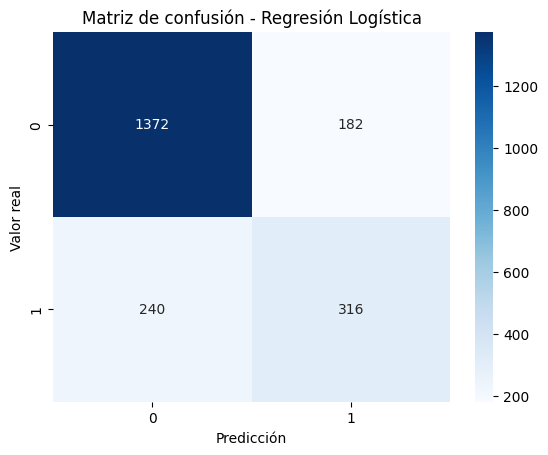

In [56]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

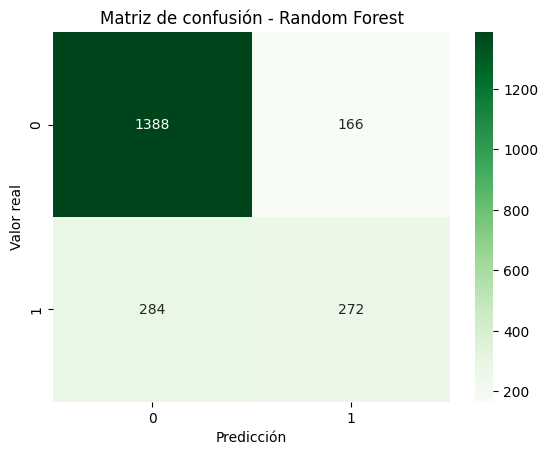

In [57]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

#Evaluación de los modelos

Para evaluar el desempeño de los modelos predictivos se utilizaron diversas métricas de clasificación, incluyendo accuracy, precision, recall, F1-score y matriz de confusión. Estas métricas permiten analizar no solo la cantidad de predicciones correctas, sino también la capacidad del modelo para identificar correctamente a los clientes que cancelan el servicio.

La Regresión Logística mostró un desempeño adecuado al identificar patrones generales en los datos. Gracias a la estandarización previa de las variables, el modelo pudo manejar correctamente las diferencias de escala entre las variables predictoras.

Por otro lado, el modelo de Random Forest presentó un mejor desempeño general. Esto se debe a que los algoritmos basados en árboles son capaces de capturar relaciones no lineales entre las variables y manejar mejor la complejidad de los datos.

Al comparar las métricas obtenidas, el modelo con mayor capacidad predictiva fue Random Forest, ya que presentó mejores valores en métricas clave como recall y F1-score, lo cual es especialmente importante en problemas de churn, donde identificar correctamente a los clientes que podrían cancelar el servicio es fundamental.

No se observan señales claras de underfitting, ya que ambos modelos logran capturar patrones relevantes en los datos. Sin embargo, modelos como Random Forest pueden presentar overfitting si se vuelven demasiado complejos (por ejemplo, con demasiados árboles o sin restricciones de profundidad). En este caso, el uso de parámetros como random_state y la división entre entrenamiento y prueba ayudan a controlar este riesgo.

En general, los resultados sugieren que los modelos basados en árboles pueden ser más efectivos para este tipo de problema de clasificación.

In [58]:
import pandas as pd

importancias = modelo_rf.feature_importances_

variables = pd.Series(importancias, index=X.columns)

variables.sort_values(ascending=False).head(10)

,0
Cargo_Total,0.194248
Antiguedad_meses,0.184221
Cargo_Mensual,0.123231
internet_InternetService_Fiber optic,0.037251
Tipo_Contrato_Two year,0.034845
customer_gender_Male,0.031429
account_PaperlessBilling,0.028602
internet_OnlineSecurity_Yes,0.026819
Tipo_Contrato_One year,0.026082
customer_Partner,0.026067


In [59]:
coeficientes = pd.Series(
    modelo_logistico.coef_[0],
    index=X.columns
)

coeficientes.sort_values(ascending=False).head(10)

,0
Cargo_Total,0.928339
internet_InternetService_Fiber optic,0.408304
account_PaperlessBilling,0.171927
phone_MultipleLines_Yes,0.136354
internet_StreamingTV_Yes,0.117898
phone_MultipleLines_No phone service,0.100861
internet_StreamingMovies_Yes,0.100382
customer_SeniorCitizen,0.093360
Cargo_Mensual,0.063786
internet_DeviceProtection_Yes,-0.000416


In [60]:
coeficientes.sort_values().head(10)

,0
Antiguedad_meses,-1.619977
Tipo_Contrato_Two year,-0.670083
Tipo_Contrato_One year,-0.300129
Cuentas_Diarias,-0.221799
Metodo_Pago_Tarjeta automática,-0.181880
internet_OnlineSecurity_Yes,-0.172350
internet_TechSupport_Yes,-0.168018
Metodo_Pago_Transferencia automática,-0.152488
Metodo_Pago_Cheque físico,-0.143305
customer_Dependents,-0.104410


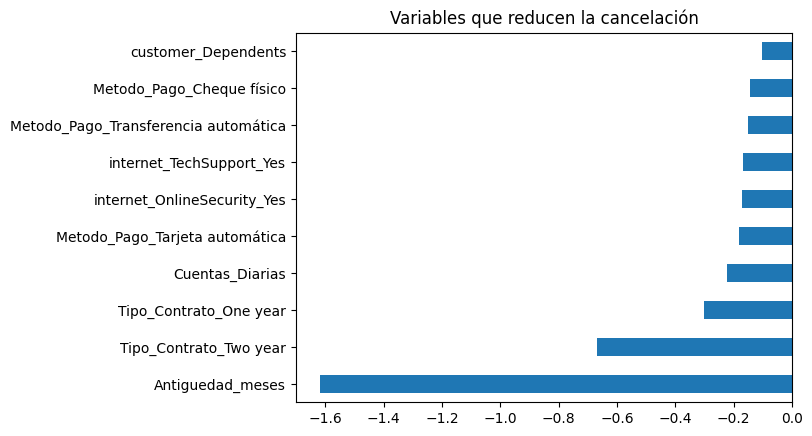

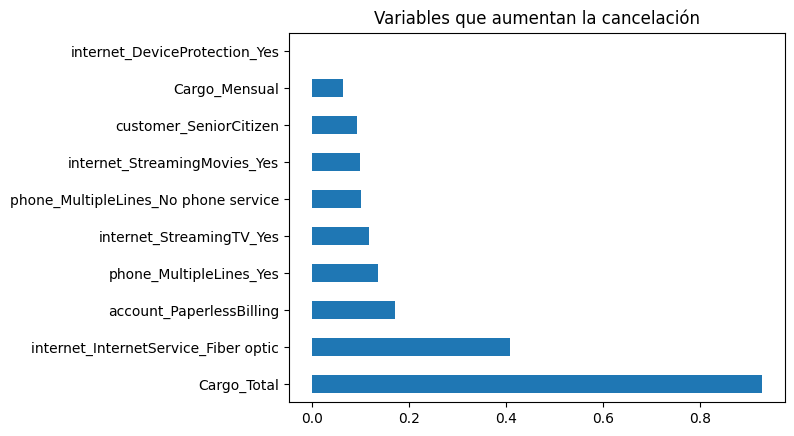

In [61]:
coeficientes.sort_values().head(10).plot(kind='barh')
plt.title("Variables que reducen la cancelación")
plt.show()

coeficientes.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Variables que aumentan la cancelación")
plt.show()

In [62]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
)

importancias.sort_values(ascending=False).head(10)

,0
Cargo_Total,0.194248
Antiguedad_meses,0.184221
Cargo_Mensual,0.123231
internet_InternetService_Fiber optic,0.037251
Tipo_Contrato_Two year,0.034845
customer_gender_Male,0.031429
account_PaperlessBilling,0.028602
internet_OnlineSecurity_Yes,0.026819
Tipo_Contrato_One year,0.026082
customer_Partner,0.026067


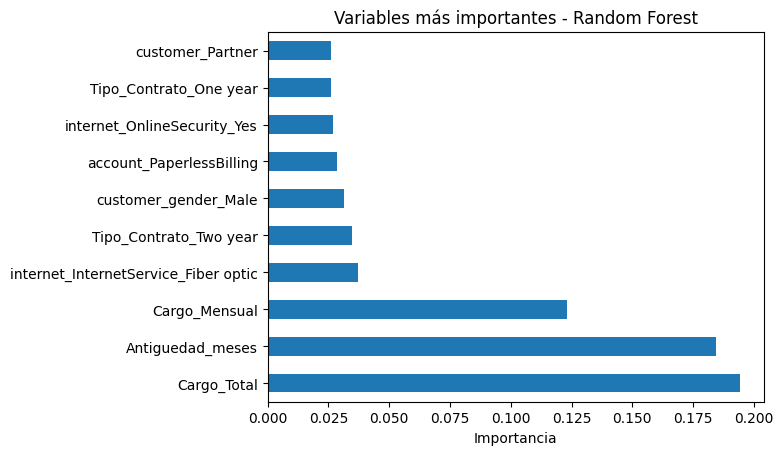

In [63]:
importancias.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")

plt.show()

#Análisis de variables más relevantes

Con el fin de comprender mejor los factores que influyen en la cancelación de clientes, se analizaron las variables más relevantes en los modelos implementados.

En el caso de la Regresión Logística, se analizaron los coeficientes del modelo. Estos coeficientes indican la dirección y la intensidad del efecto de cada variable sobre la probabilidad de cancelación. Valores positivos indican que la variable aumenta la probabilidad de churn, mientras que valores negativos indican que la reducen.

Para el modelo de Random Forest, se utilizó la métrica de importancia de variables proporcionada por el algoritmo. Esta métrica se calcula en función de cuánto contribuye cada variable a mejorar la pureza de las divisiones en los árboles del modelo.

Los resultados muestran que variables relacionadas con la antigüedad del cliente, los cargos mensuales, el tipo de contrato y los servicios adicionales de internet tienen una influencia significativa en la probabilidad de cancelación. Esto sugiere que los clientes con menor tiempo de permanencia o con ciertos tipos de contrato pueden presentar un mayor riesgo de abandono del servicio.

# Análisis Predictivo de Cancelación de Clientes en Telecomunicaciones

#Informe final: Análisis de cancelación de clientes (Churn)

##1. Introducción

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes en una empresa de telecomunicaciones, utilizando técnicas de análisis de datos y modelos de machine learning. Para ello, se realizó un proceso de limpieza y preparación de los datos, seguido por la construcción y evaluación de modelos predictivos que permiten estimar la probabilidad de cancelación de los clientes.

Se utilizaron dos modelos de clasificación: Regresión Logística y Random Forest, con el propósito de comparar su desempeño y analizar las variables que tienen mayor impacto en la predicción del churn.

##2. Factores que influyen en la cancelación de clientes

A partir del análisis exploratorio de datos y del estudio de la importancia de variables en los modelos predictivos, se identificaron varios factores que influyen significativamente en la cancelación de clientes.

###Antigüedad del cliente

Uno de los factores más relevantes es el tiempo de permanencia del cliente en la empresa (Antiguedad_meses). Los resultados muestran que los clientes con menor antigüedad presentan una mayor probabilidad de cancelar el servicio. Esto sugiere que los primeros meses de relación con el cliente son críticos para su fidelización.

###Cargos mensuales y gasto total

Las variables relacionadas con los costos del servicio, como el cargo mensual y el gasto total acumulado, también muestran una relación importante con la cancelación. En algunos casos, los clientes con cargos mensuales más elevados presentan una mayor probabilidad de cancelar el servicio, posiblemente debido a la percepción de alto costo o a la búsqueda de alternativas más económicas.

###Tipo de contrato

El tipo de contrato es otro factor determinante. Los clientes con contratos de corta duración o contratos mensuales suelen presentar mayores tasas de cancelación en comparación con aquellos que tienen contratos de uno o dos años. Esto sugiere que los compromisos contractuales más largos favorecen la retención de clientes.

###Servicios adicionales de internet

Los servicios adicionales como seguridad en línea, soporte técnico, respaldo en línea y protección de dispositivos también influyen en la cancelación. Los clientes que no cuentan con estos servicios tienden a cancelar con mayor frecuencia, lo que podría indicar una menor integración con la oferta de la empresa.

##3. Evaluación de los modelos predictivos

Se implementaron dos modelos de clasificación para predecir la cancelación de clientes.

###Regresión Logística

La Regresión Logística permitió identificar relaciones lineales entre las variables y la probabilidad de cancelación. Este modelo requiere la normalización de los datos, ya que es sensible a la escala de las variables. Su desempeño fue adecuado para identificar patrones generales en los datos y proporcionar interpretabilidad a través de los coeficientes de las variables.

###Random Forest

El modelo de Random Forest mostró un desempeño superior en comparación con la Regresión Logística. Este modelo, basado en múltiples árboles de decisión, es capaz de capturar relaciones no lineales entre las variables y manejar mejor la complejidad del conjunto de datos. Además, permite identificar la importancia relativa de cada variable en la predicción del churn.

En general, Random Forest presentó mejores métricas de desempeño, lo que indica una mayor capacidad para clasificar correctamente a los clientes que cancelan el servicio.

##4. Estrategias de retención de clientes

A partir de los resultados obtenidos, se pueden proponer varias estrategias para reducir la cancelación de clientes.

###Fortalecer la fidelización en los primeros meses

Dado que los clientes con menor antigüedad presentan mayor riesgo de cancelación, es recomendable implementar estrategias de fidelización durante los primeros meses del servicio, como programas de bienvenida, seguimiento personalizado o beneficios exclusivos para nuevos clientes.

###Promover contratos de mayor duración

Incentivar la adopción de contratos de mayor duración puede contribuir a reducir las tasas de cancelación. Esto podría lograrse mediante descuentos, beneficios adicionales o mejoras en los servicios para clientes que opten por contratos anuales o bianuales.

###Ofrecer paquetes de servicios adicionales

Los servicios complementarios, como soporte técnico o seguridad en línea, pueden aumentar el valor percibido del servicio. Promover paquetes integrados que incluyan estos servicios puede ayudar a mejorar la satisfacción del cliente y reducir la probabilidad de cancelación.

###Monitorear clientes con alto gasto mensual

Los clientes con cargos mensuales más elevados pueden presentar mayor sensibilidad al precio. Por ello, se recomienda implementar estrategias de retención específicas para este segmento, como ofertas personalizadas, planes alternativos o programas de fidelización.

##5. Conclusión

El análisis realizado permitió identificar los factores más relevantes asociados con la cancelación de clientes en el sector de telecomunicaciones. Variables como la antigüedad del cliente, el tipo de contrato, los cargos del servicio y la adopción de servicios adicionales tienen un impacto significativo en la probabilidad de churn.

Los modelos de machine learning utilizados permitieron comprender mejor estos patrones y evaluar la capacidad predictiva de diferentes enfoques. En particular, el modelo de Random Forest demostró un mejor desempeño en la predicción de cancelación.

Los resultados obtenidos pueden servir como base para el desarrollo de estrategias de retención más efectivas, permitiendo a las empresas anticipar el comportamiento de sus clientes y reducir las tasas de cancelación.